# Analysis of the APS results for the LLama model

# First analysis: Are the prediction sets leaning to the correct veracity label?

### We consider that 'true', 'mostly-true', 'half-true' into the true category and 'mostly-false', 'false' and 'pants-fire' into the false category

We want to see if a prediction set have more true labels and false labels and to see if the label of the statement corresponds into the same category as the majority of the statements

In [1]:
import pandas as pd
import ast

true_side_labels = {"true", "mostly-true", "half-true"}
false_side_labels = {"mostly-false", "false", "pants-fire"}

def verdict_side(verdict):
    if verdict in true_side_labels:
        return "true"
    if verdict in false_side_labels:
        return "false"
    return "unknown"

def parse_prediction_set(value):
    if isinstance(value, str):
        return ast.literal_eval(value)
    return value

def prediction_set_side(prediction_set):
    labels = parse_prediction_set(prediction_set)
    true_count = sum(label in true_side_labels for label in labels)
    false_count = sum(label in false_side_labels for label in labels)

    if true_count > false_count:
        return "true"
    if false_count > true_count:
        return "false"
    return "neutral"

def check_prediction_set(df):
    df["true_side"] = df["true_verdict"].apply(verdict_side)
    df["prediction_side"] = df["prediction_set"].apply(prediction_set_side)

    df["side_matches"] = df["prediction_side"] == df["true_side"]
    df["is_neutral"] = df["prediction_side"] == "neutral"

    total_rows = len(df)
    match_rate_all = df["side_matches"].mean()
    neutral_rate = df["is_neutral"].mean()

    non_neutral = df[~df["is_neutral"]]
    match_rate_non_neutral = non_neutral["side_matches"].mean() if len(non_neutral) else float("nan")

    print(f"Rows: {total_rows}")
    print(f"Prediction sets leaning to the correct side: {df['side_matches'].sum()} / {total_rows}")
    print(f"Match rate including neutral sets: {match_rate_all:.3f}")
    print(f"Neutral rate: {neutral_rate:.3f}")
    print(f"Match rate excluding neutral sets: {match_rate_non_neutral:.3f}")

    # Optional: show a few examples
    df[["true_verdict", "prediction_set", "true_side", "prediction_side", "side_matches"]].head(10)

## Gather the results for no evidence and evidence 

### Show for each category how are the prediction sets leaning to 

In [2]:
no_evidence_aps_llama_csv = {
    'crime': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/llama/zero-shot-aps/crime/conformal_results_aps_all_trials_100trials_20260501_010529.csv",
    'economy': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/llama/zero-shot-aps/economy/conformal_results_aps_all_trials_100trials_20260501_030659.csv",
    'education': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/llama/zero-shot-aps/education/conformal_results_aps_all_trials_100trials_20260501_022015.csv",
    'elections': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/llama/zero-shot-aps/elections/conformal_results_aps_all_trials_100trials_20260501_032421.csv",
    'health-care': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/llama/zero-shot-aps/health-care/conformal_results_aps_all_trials_100trials_20260501_042748.csv",
    'immigration': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/llama/zero-shot-aps/immigration/conformal_results_aps_all_trials_100trials_20260501_034726.csv",
    'jobs': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/llama/zero-shot-aps/jobs/conformal_results_aps_all_trials_100trials_20260501_033545.csv",
    'taxes': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/llama/zero-shot-aps/taxes/conformal_results_aps_all_trials_100trials_20260501_043609.csv"
}

with_evidence_aps_llama_csv = {
    'crime': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/llama/zero-shot-aps-evidence/crime/conformal_results_aps_all_trials_100trials_20260503_174721.csv",
    'economy': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/llama/zero-shot-aps-evidence/economy/conformal_results_aps_all_trials_100trials_20260503_233854.csv",
    'education': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/llama/zero-shot-aps-evidence/education/conformal_results_aps_all_trials_100trials_20260503_221646.csv",
    'elections': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/llama/zero-shot-aps-evidence/elections/conformal_results_aps_all_trials_100trials_20260504_011728.csv",
    'health-care': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/llama/zero-shot-aps-evidence/health-care/conformal_results_aps_all_trials_100trials_20260504_034503.csv",
    'immigration': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/llama/zero-shot-aps-evidence/immigration/conformal_results_aps_all_trials_100trials_20260505_175416.csv",
    'jobs': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/llama/zero-shot-aps-evidence/jobs/conformal_results_aps_all_trials_100trials_20260503_233509.csv",
    'taxes': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/llama/zero-shot-aps-evidence/taxes/conformal_results_aps_all_trials_100trials_20260504_044716.csv"
}

for category in no_evidence_aps_llama_csv.keys():
    print(f"Category: {category}")
    print("Without evidence:")
    df_no_evidence = pd.read_csv(no_evidence_aps_llama_csv[category])
    check_prediction_set(df_no_evidence)
    
    print("\nWith evidence:")
    df_with_evidence = pd.read_csv(with_evidence_aps_llama_csv[category])
    check_prediction_set(df_with_evidence)
    
    print("\n" + "="*50 + "\n")

Category: crime
Without evidence:
Rows: 55000
Prediction sets leaning to the correct side: 32404 / 55000
Match rate including neutral sets: 0.589
Neutral rate: 0.148
Match rate excluding neutral sets: 0.692

With evidence:
Rows: 55000
Prediction sets leaning to the correct side: 42572 / 55000
Match rate including neutral sets: 0.774
Neutral rate: 0.164
Match rate excluding neutral sets: 0.926


Category: economy
Without evidence:
Rows: 97800
Prediction sets leaning to the correct side: 56642 / 97800
Match rate including neutral sets: 0.579
Neutral rate: 0.146
Match rate excluding neutral sets: 0.678

With evidence:
Rows: 97800
Prediction sets leaning to the correct side: 75673 / 97800
Match rate including neutral sets: 0.774
Neutral rate: 0.143
Match rate excluding neutral sets: 0.903


Category: education
Without evidence:
Rows: 67600
Prediction sets leaning to the correct side: 36935 / 67600
Match rate including neutral sets: 0.546
Neutral rate: 0.154
Match rate excluding neutral set

In [10]:
"""
Visualize prediction-set evaluation results with and without evidence.

Produces four charts:
  1. Dumbbell chart       - lift from evidence per category
  2. 100% stacked bars    - correct / neutral / incorrect breakdown
  3. Scatter vs. y=x      - with-evidence vs. without-evidence accuracy
  4. Grouped bar chart    - simple side-by-side accuracy comparison
"""

import matplotlib.pyplot as plt
import numpy as np

# ---------------------------------------------------------------------------
# Data (paste your numbers here, or compute them from your DataFrame)
# ---------------------------------------------------------------------------
results = {
    "crime":       {"without": (0.589, 0.148), "with": (0.774, 0.164)},
    "economy":     {"without": (0.579, 0.146), "with": (0.774, 0.143)},
    "education":   {"without": (0.546, 0.154), "with": (0.714, 0.193)},
    "elections":   {"without": (0.620, 0.142), "with": (0.792, 0.139)},
    "health-care": {"without": (0.569, 0.126), "with": (0.771, 0.153)},
    "immigration": {"without": (0.587, 0.145), "with": (0.735, 0.178)},
    "jobs":        {"without": (0.576, 0.131), "with": (0.761, 0.147)},
    "taxes":       {"without": (0.538, 0.157), "with": (0.753, 0.162)},
}

# Sort by size of lift (with - without) for a tidier dumbbell chart
categories = sorted(results.keys(),
                    key=lambda c: results[c]["with"][0] - results[c]["without"][0])

without_correct = np.array([results[c]["without"][0] for c in categories])
with_correct    = np.array([results[c]["with"][0]    for c in categories])
without_neutral = np.array([results[c]["without"][1] for c in categories])
with_neutral    = np.array([results[c]["with"][1]    for c in categories])
without_wrong   = 1 - without_correct - without_neutral
with_wrong      = 1 - with_correct - with_neutral

# Color palette
C_WITHOUT = "#d97757"   # warm orange
C_WITH    = "#3a7d7b"   # teal
C_CORRECT = "#3a7d7b"
C_NEUTRAL = "#c8c2b6"
C_WRONG   = "#d97757"

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.titleweight":  "bold",
    "axes.titlesize":    13,
})


# ---------------------------------------------------------------------------
# 2. 100% stacked bar chart
# ---------------------------------------------------------------------------
def stacked_bar_chart(path):
    fig, ax = plt.subplots(figsize=(11, 7))
    x = np.arange(len(categories))
    width = 0.38

    # Without evidence (left bar of each pair) — hatched
    ax.bar(x - width / 2, without_correct, width,
           color=C_CORRECT, hatch="//", edgecolor="white")
    ax.bar(x - width / 2, without_neutral, width, bottom=without_correct,
           color=C_NEUTRAL, hatch="//", edgecolor="white")
    ax.bar(x - width / 2, without_wrong, width,
           bottom=without_correct + without_neutral,
           color=C_WRONG, hatch="//", edgecolor="white")

    # With evidence (right bar of each pair) — solid
    ax.bar(x + width / 2, with_correct, width,
           color=C_CORRECT, edgecolor="white")
    ax.bar(x + width / 2, with_neutral, width, bottom=with_correct,
           color=C_NEUTRAL, edgecolor="white")
    ax.bar(x + width / 2, with_wrong, width,
           bottom=with_correct + with_neutral,
           color=C_WRONG, edgecolor="white")

    # numeric labels on the "correct" (teal) segment
    for xi, v in zip(x - width / 2, without_correct):
        ax.text(xi, v / 2, f"{v:.2f}", ha="center", va="center",
                color="white", fontsize=13, fontweight="bold")
    for xi, v in zip(x + width / 2, with_correct):
        ax.text(xi, v / 2, f"{v:.2f}", ha="center", va="center",
                color="white", fontsize=13, fontweight="bold")

    # numeric labels on the "incorrect" (orange) segment
    for xi, v_bot, v_wrong in zip(x - width / 2,
                                   without_correct + without_neutral,
                                   without_wrong):
        mid = v_bot + v_wrong / 2
        ax.text(xi, mid, f"{v_wrong:.2f}", ha="center", va="center",
                color="white", fontsize=13, fontweight="bold")
    for xi, v_bot, v_wrong in zip(x + width / 2,
                                   with_correct + with_neutral,
                                   with_wrong):
        mid = v_bot + v_wrong / 2
        ax.text(xi, mid, f"{v_wrong:.2f}", ha="center", va="center",
                color="white", fontsize=13, fontweight="bold")

    # "no ev." / "ev." sub-labels under each bar pair
    for xi in x:
        ax.text(xi - width / 2, -0.025, "no ev.", ha="center", va="top",
                fontsize=7.5, color="#666")
        ax.text(xi + width / 2, -0.025, "ev.",    ha="center", va="top",
                fontsize=7.5, color="#666")

    ax.set_xticks(x)
    ax.set_xticklabels(categories, rotation=20, ha="right")
    ax.tick_params(axis="x", pad=18)
    ax.set_ylim(0, 1)
    ax.set_ylabel("Share of prediction sets")

    # Title only at top
    fig.suptitle("Prediction outcome breakdown by category for Llama using APS",
                 fontsize=14, fontweight="bold", y=0.97)

    # Two legends below the x-axis (moved lower)
    outcome_handles = [
        plt.Rectangle((0, 0), 1, 1, color=C_CORRECT, label="Correct"),
        plt.Rectangle((0, 0), 1, 1, color=C_NEUTRAL, label="Neutral"),
        plt.Rectangle((0, 0), 1, 1, color=C_WRONG,   label="Incorrect"),
    ]
    condition_handles = [
        plt.Rectangle((0, 0), 1, 1, facecolor="white", edgecolor="#555",
                      hatch="//", label="Without evidence"),
        plt.Rectangle((0, 0), 1, 1, facecolor="#555", edgecolor="#555",
                      label="With evidence"),
    ]
    leg1 = ax.legend(handles=outcome_handles, title="Outcome",
                     loc="upper center", bbox_to_anchor=(0.30, -0.16),
                     ncol=3, frameon=False)
    ax.add_artist(leg1)
    ax.legend(handles=condition_handles, title="Condition",
              loc="upper center", bbox_to_anchor=(0.78, -0.16),
              ncol=2, frameon=False)

    # Description slightly lower to sit closer to legends
    # fig.text(
    #     0.5, 0.007,
    #     "We check whether each prediction set leans to the correct truth side (true vs. false).\n"
    #     "A prediction set leans 'correctly' when the majority of labels in the set are on the same truth side as the ground truth,\n"
    #     "'incorrectly' when the majority leans the opposite way, and 'neutral' when counts are tied.\n"
    #     "Left bar (hatched) = model WITHOUT evidence.   Right bar (solid) = model WITH evidence.",
    #     ha="center", va="top", fontsize=12.0, color="#444",
    # )

    plt.tight_layout(rect=[0, 0.00, 1, 0.94])
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.close(fig)


# ---------------------------------------------------------------------------
if __name__ == "__main__":

    stacked_bar_chart("visualisations_APS/stacked_bar_aps.png")
    print("Saved: visualisations_APS/stacked_bar_aps.png")

Saved: visualisations_APS/stacked_bar_aps.png


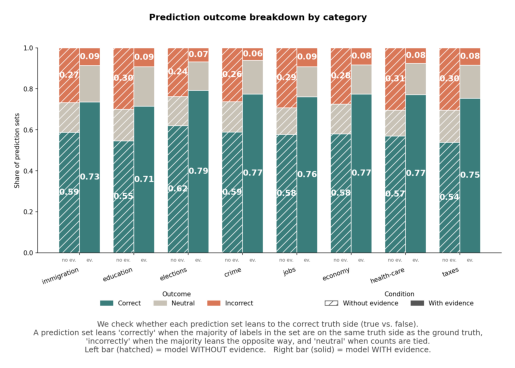

In [13]:
# Display the stacked bar

import matplotlib.pyplot as plt
img = plt.imread("visualisations_APS/stacked_bar.png")
plt.imshow(img); plt.axis("off"); plt.show()

# Conclusion from the first analysis:

# Second analysis: What are the distribution for each of the prediction set size (e.g., 1,2,3,4,5,6)?
### For each category, we will see the distribution of each prediction set sizes (how many are of size 1, 2, 3, 4, 5 and 6)


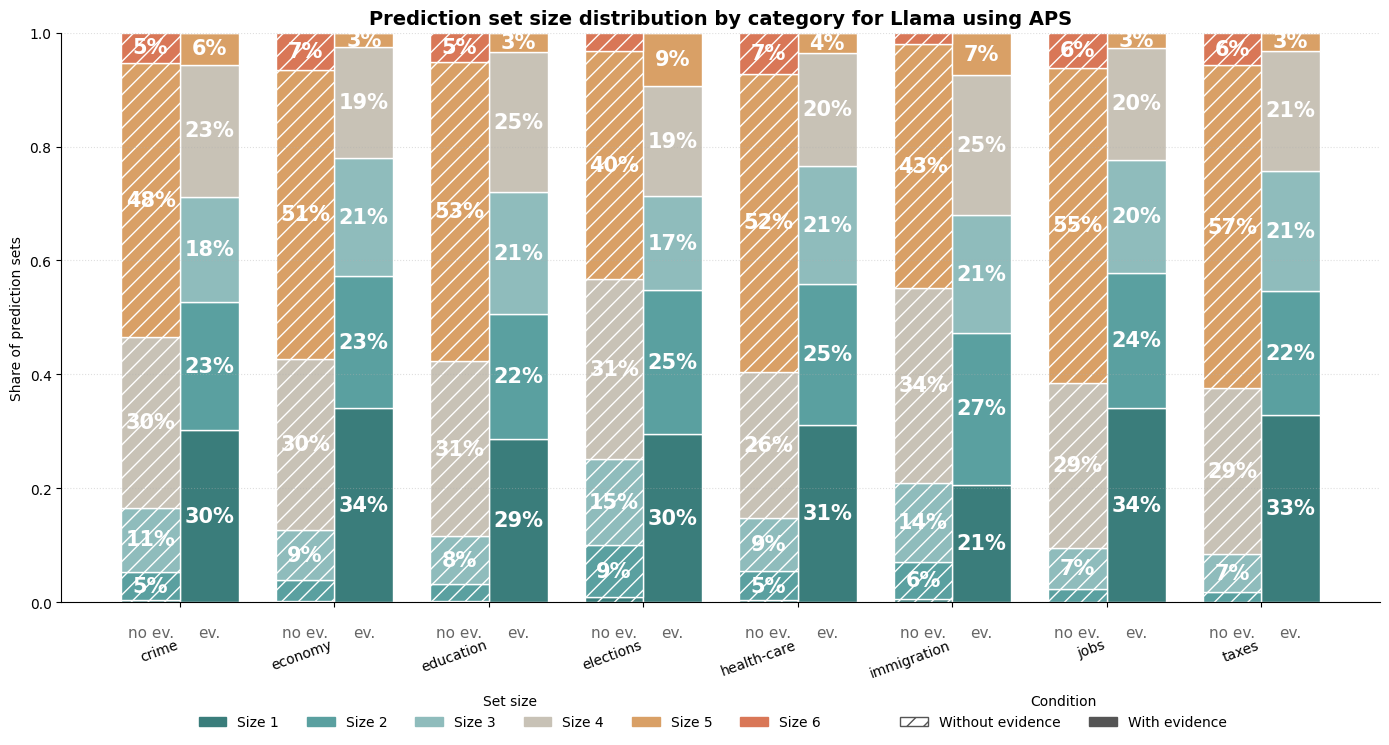

Saved: visualisations_APS/set_size_distribution_aps.png


In [5]:
import os
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def parse_prediction_set(value):
    if isinstance(value, str):
        return ast.literal_eval(value)
    return value

def ensure_set_size(df):
    if "set_size" not in df.columns:
        df = df.copy()
        df["set_size"] = df["prediction_set"].apply(lambda x: len(parse_prediction_set(x)))
    return df

def get_size_percentages(csv_path):
    df = pd.read_csv(csv_path)
    df = ensure_set_size(df)
    counts = df["set_size"].value_counts().reindex([1, 2, 3, 4, 5, 6], fill_value=0)
    return counts / counts.sum()

def plot_all_categories_set_sizes(no_evidence_aps_llama_csv, with_evidence_aps_llama_csv, output_path="visualisations_APS/set_size_distribution_aps.png"):
    categories = list(no_evidence_aps_llama_csv.keys())
    sizes = [1, 2, 3, 4, 5, 6]

    no_data = {cat: get_size_percentages(no_evidence_aps_llama_csv[cat]) for cat in categories}
    with_data = {cat: get_size_percentages(with_evidence_aps_llama_csv[cat]) for cat in categories}

    colors = ["#3a7d7b", "#5aa0a0", "#8fbcbc", "#c8c2b6", "#d9a066", "#d97757"]

    x = np.arange(len(categories))
    width = 0.38

    fig, ax = plt.subplots(figsize=(14, 8))

    for i, size in enumerate(sizes):
        no_bottom = np.array([sum(no_data[cat].iloc[:i]) for cat in categories])
        with_bottom = np.array([sum(with_data[cat].iloc[:i]) for cat in categories])

        no_vals = np.array([no_data[cat].iloc[i] for cat in categories])
        with_vals = np.array([with_data[cat].iloc[i] for cat in categories])

        ax.bar(
            x - width / 2,
            no_vals,
            width,
            bottom=no_bottom,
            color=colors[i],
            edgecolor="white",
            hatch="//",
        )
        ax.bar(
            x + width / 2,
            with_vals,
            width,
            bottom=with_bottom,
            color=colors[i],
            edgecolor="white",
        )

        for xi, bottom, val in zip(x - width / 2, no_bottom, no_vals):
            if val >= 0.04:
                ax.text(
                    xi,
                    bottom + val / 2,
                    f"{val:.0%}",
                    ha="center",
                    va="center",
                    fontsize=15,
                    color="white",
                    fontweight="bold",
                )

        for xi, bottom, val in zip(x + width / 2, with_bottom, with_vals):
            if val >= 0.01:
                ax.text(
                    xi,
                    bottom + val / 2,
                    f"{val:.0%}",
                    ha="center",
                    va="center",
                    fontsize=15,
                    color="white",
                    fontweight="bold",
                )

    for xi in x:
        ax.text(xi - width / 2, -0.04, "no ev.", ha="center", va="top", fontsize=11, color="#666")
        ax.text(xi + width / 2, -0.04, "ev.", ha="center", va="top", fontsize=11, color="#666")

    ax.set_xticks(x)
    ax.set_xticklabels(categories, rotation=20, ha="right")
    ax.tick_params(axis="x", pad=22)
    ax.set_ylim(0, 1)
    ax.set_ylabel("Share of prediction sets")
    ax.set_title("Prediction set size distribution by category for Llama using APS", fontsize=14, fontweight="bold")
    ax.grid(axis="y", linestyle=":", alpha=0.4)

    condition_handles = [
        plt.Rectangle((0, 0), 1, 1, facecolor="white", edgecolor="#555", hatch="//", label="Without evidence"),
        plt.Rectangle((0, 0), 1, 1, facecolor="#555", edgecolor="#555", label="With evidence"),
    ]
    size_handles = [
        plt.Rectangle((0, 0), 1, 1, color=colors[i], label=f"Size {sizes[i]}")
        for i in range(len(sizes))
    ]

    leg1 = ax.legend(
        handles=size_handles,
        title="Set size",
        loc="upper center",
        bbox_to_anchor=(0.34, -0.14),
        ncol=6,
        frameon=False,
    )
    ax.add_artist(leg1)

    ax.legend(
        handles=condition_handles,
        title="Condition",
        loc="upper center",
        bbox_to_anchor=(0.76, -0.14),
        ncol=2,
        frameon=False,
    )

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.24)
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)

plot_all_categories_set_sizes(no_evidence_aps_llama_csv, with_evidence_aps_llama_csv, output_path="visualisations_APS/set_size_distribution_aps.png")
print("Saved: visualisations_APS/set_size_distribution_aps.png")

# Conclusion from the second analysis:

# Third analysis: What were the true label of the statements whose prediction set did not include it?

### Look for each of the failed prediction sets what should have them include

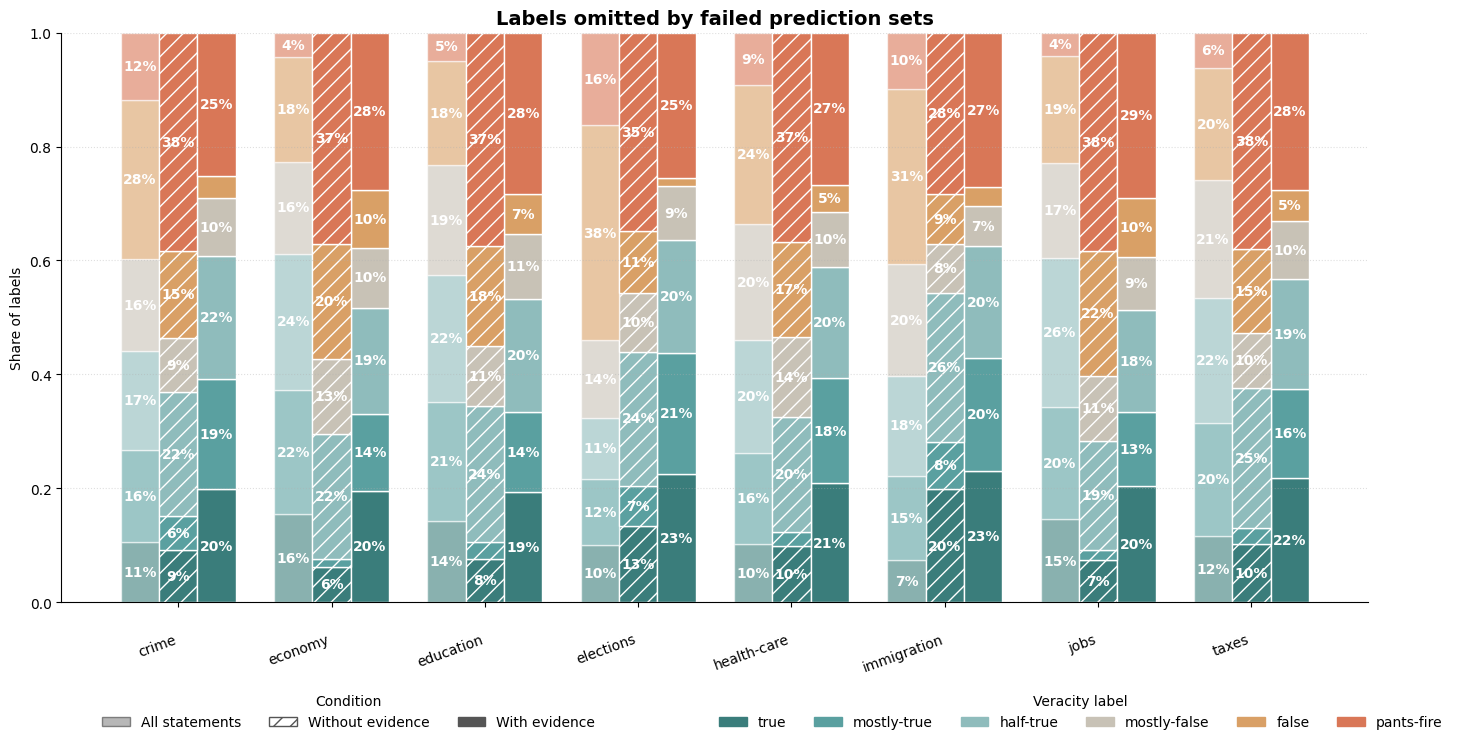

Saved: visualisations_APS/failed_set_omissions_by_category.png


In [6]:
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

LABEL_ORDER = ["true", "mostly-true", "half-true", "mostly-false", "false", "pants-fire"]

def parse_prediction_set(value):
    if isinstance(value, str):
        return ast.literal_eval(value)
    return value

def get_failed_set_label_distribution(csv_path):
    df = pd.read_csv(csv_path)

    if "is_covered" not in df.columns:
        raise ValueError(f"{csv_path} does not contain an 'is_covered' column.")

    total_prediction_sets = len(df)
    failed_df = df[df["is_covered"] == False].copy()
    failed_df["prediction_set"] = failed_df["prediction_set"].apply(parse_prediction_set)

    omitted_counts = {label: 0 for label in LABEL_ORDER}
    total_omissions = 0

    for pred_set in failed_df["prediction_set"]:
        pred_set = set(pred_set)
        omitted_labels = [label for label in LABEL_ORDER if label not in pred_set]
        for label in omitted_labels:
            omitted_counts[label] += 1
            total_omissions += 1

    if total_omissions == 0:
        proportions = pd.Series({label: 0 for label in LABEL_ORDER})
    else:
        proportions = pd.Series(
            {label: omitted_counts[label] / total_omissions for label in LABEL_ORDER}
        )

    failed_rate = len(failed_df) / total_prediction_sets if total_prediction_sets else 0
    return proportions, len(failed_df), failed_rate

def get_all_statements_label_distribution(csv_path):
    df = pd.read_csv(csv_path)

    if "true_verdict" not in df.columns:
        raise ValueError(f"{csv_path} does not contain a 'true_verdict' column.")

    counts = df["true_verdict"].value_counts().reindex(LABEL_ORDER, fill_value=0)
    proportions = counts / counts.sum() if counts.sum() else counts
    return proportions, len(df)

def plot_failed_set_omissions(no_evidence_aps_llama_csv, with_evidence_aps_llama_csv, output_path="visualisations_LAC/failed_set_omissions_by_category.png"):
    categories = list(no_evidence_aps_llama_csv.keys())

    label_colors = {
        "true": "#3a7d7b",
        "mostly-true": "#5aa0a0",
        "half-true": "#8fbcbc",
        "mostly-false": "#c8c2b6",
        "false": "#d9a066",
        "pants-fire": "#d97757",
    }

    no_data = {}
    with_data = {}
    all_data = {}
    no_failed_rates = {}
    with_failed_rates = {}

    for category in categories:
        no_props, no_failed, no_failed_rate = get_failed_set_label_distribution(no_evidence_aps_llama_csv[category])
        with_props, with_failed, with_failed_rate = get_failed_set_label_distribution(with_evidence_aps_llama_csv[category])
        all_props, total_count = get_all_statements_label_distribution(no_evidence_aps_llama_csv[category])

        no_data[category] = no_props
        with_data[category] = with_props
        all_data[category] = all_props
        no_failed_rates[category] = no_failed_rate
        with_failed_rates[category] = with_failed_rate

    x = np.arange(len(categories))
    width = 0.25

    fig, ax = plt.subplots(figsize=(15, 8))

    no_bottom = np.zeros(len(categories))
    with_bottom = np.zeros(len(categories))
    all_bottom = np.zeros(len(categories))

    for label in LABEL_ORDER:
        no_vals = np.array([no_data[cat][label] for cat in categories])
        with_vals = np.array([with_data[cat][label] for cat in categories])
        all_vals = np.array([all_data[cat][label] for cat in categories])

        ax.bar(
            x - width,
            all_vals,
            width,
            bottom=all_bottom,
            color=label_colors[label],
            edgecolor="white",
            alpha=0.6,
        )
        ax.bar(
            x,
            no_vals,
            width,
            bottom=no_bottom,
            color=label_colors[label],
            edgecolor="white",
            hatch="//",
        )
        ax.bar(
            x + width,
            with_vals,
            width,
            bottom=with_bottom,
            color=label_colors[label],
            edgecolor="white",
        )

        for xi, bottom, val in zip(x - width, all_bottom, all_vals):
            if val >= 0.04:
                ax.text(
                    xi,
                    bottom + val / 2,
                    f"{val:.0%}",
                    ha="center",
                    va="center",
                    fontsize=10,
                    color="white",
                    fontweight="bold",
                )

        for xi, bottom, val in zip(x, no_bottom, no_vals):
            if val >= 0.04:
                ax.text(
                    xi,
                    bottom + val / 2,
                    f"{val:.0%}",
                    ha="center",
                    va="center",
                    fontsize=10,
                    color="white",
                    fontweight="bold",
                )

        for xi, bottom, val in zip(x + width, with_bottom, with_vals):
            if val >= 0.04:
                ax.text(
                    xi,
                    bottom + val / 2,
                    f"{val:.0%}",
                    ha="center",
                    va="center",
                    fontsize=10,
                    color="white",
                    fontweight="bold",
                )

        all_bottom += all_vals
        no_bottom += no_vals
        with_bottom += with_vals

    ax.set_ylim(0, 1)
    ax.set_xticks(x)
    ax.set_xticklabels(categories, rotation=20, ha="right")
    ax.tick_params(axis="x", pad=18)
    ax.set_ylabel("Share of labels")
    ax.set_title("Labels omitted by failed prediction sets", fontsize=14, fontweight="bold")
    ax.grid(axis="y", linestyle=":", alpha=0.4)

    condition_handles = [
        plt.Rectangle((0, 0), 1, 1, facecolor="#999", edgecolor="#555", alpha=0.7, label="All statements"),
        plt.Rectangle((0, 0), 1, 1, facecolor="white", edgecolor="#555", hatch="//", label="Without evidence"),
        plt.Rectangle((0, 0), 1, 1, facecolor="#555", edgecolor="#555", label="With evidence"),
    ]
    label_handles = [
        plt.Rectangle((0, 0), 1, 1, color=label_colors[label], label=label)
        for label in LABEL_ORDER
    ]

    leg1 = ax.legend(
        handles=condition_handles,
        title="Condition",
        bbox_to_anchor=(0.22, -0.14),
        loc="upper center",
        ncol=3,
        frameon=False,
    )
    ax.add_artist(leg1)

    ax.legend(
        handles=label_handles,
        title="Veracity label",
        bbox_to_anchor=(0.78, -0.14),
        loc="upper center",
        ncol=6,
        frameon=False,
    )

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.24)
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)

plot_failed_set_omissions(no_evidence_aps_llama_csv, with_evidence_aps_llama_csv)
print("Saved: visualisations_APS/failed_set_omissions_by_category.png")

# Conclusion from the third analysis:




# Fourth Analysis: Show performance in terms of prediction sets for both evidence and non evidence


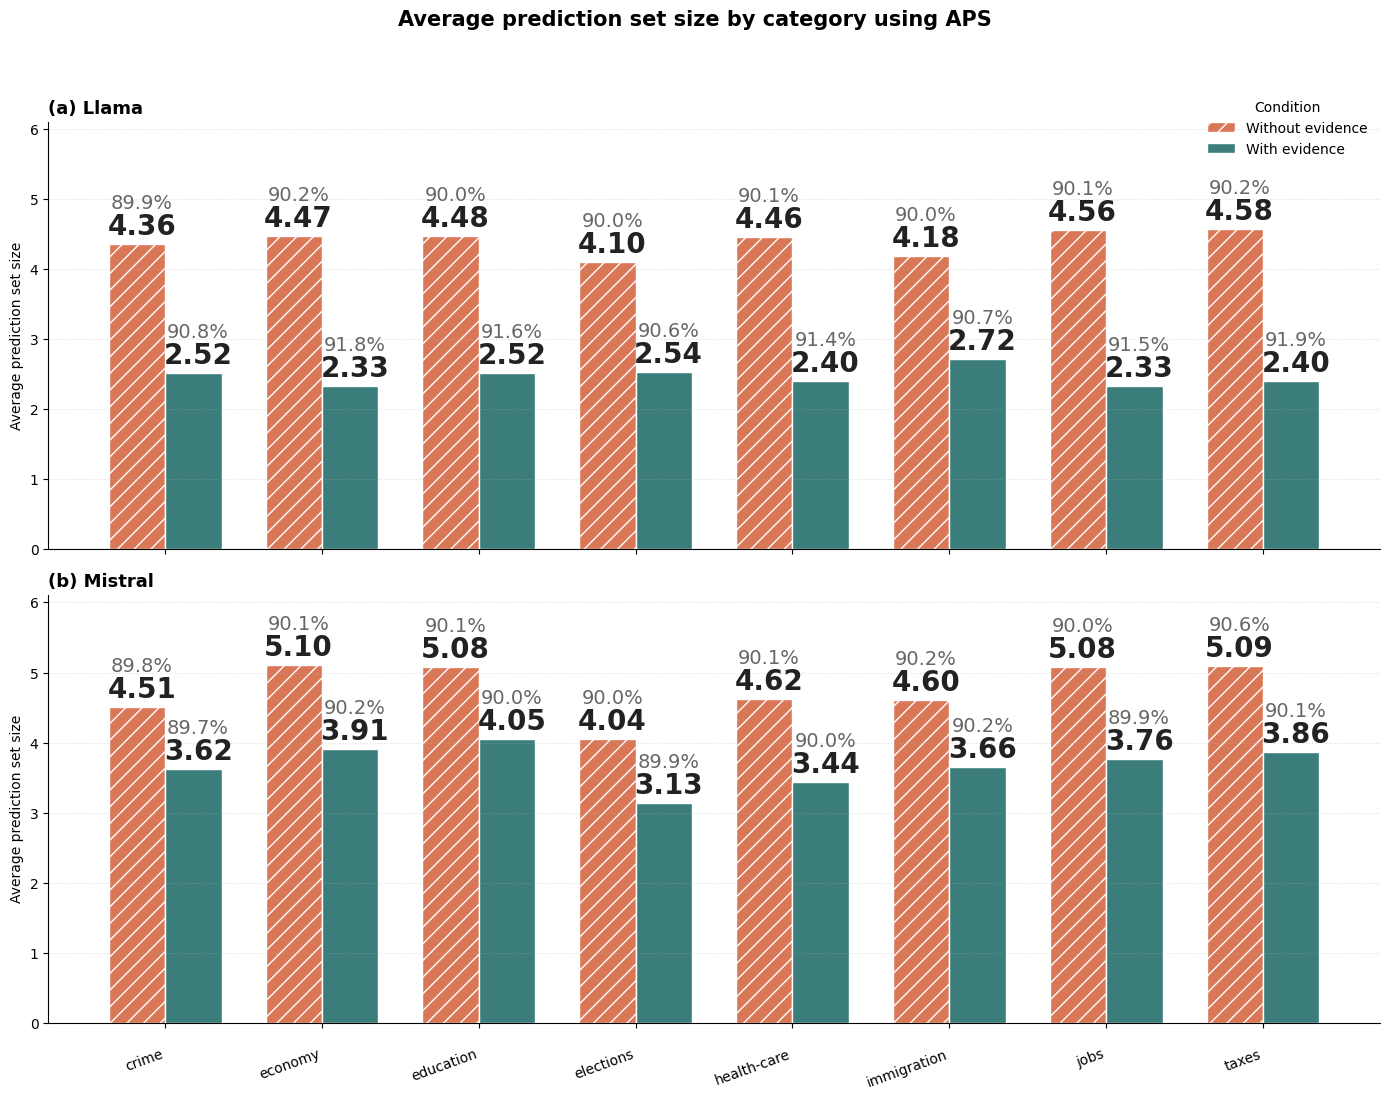

Saved: visualisations_APS/average_prediction_set_sizes_aps.png


In [7]:
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

no_evidence_aps_mistral_csv = {
    'crime': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/mistral/zero-shot-aps/crime/conformal_results_aps_all_trials_100trials_20260501_034109.csv",
    'economy': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/mistral/zero-shot-aps/economy/conformal_results_aps_all_trials_100trials_20260501_062603.csv",
    'education': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/mistral/zero-shot-aps/education/conformal_results_aps_all_trials_100trials_20260501_042519.csv",
    'elections': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/mistral/zero-shot-aps/elections/conformal_results_aps_all_trials_100trials_20260501_063924.csv",
    'health-care': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/mistral/zero-shot-aps/health-care/conformal_results_aps_all_trials_100trials_20260501_065153.csv",
    'immigration': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/mistral/zero-shot-aps/immigration/conformal_results_aps_all_trials_100trials_20260501_054829.csv",
    'jobs': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/mistral/zero-shot-aps/jobs/conformal_results_aps_all_trials_100trials_20260501_053623.csv",
    'taxes': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/mistral/zero-shot-aps/taxes/conformal_results_aps_all_trials_100trials_20260502_123934.csv"
}

with_evidence_aps_mistral_csv = {
    'crime': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/mistral/zero-shot-aps-evidence/crime/conformal_results_aps_all_trials_100trials_20260504_171419.csv",
    'economy': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/mistral/zero-shot-aps-evidence/economy/conformal_results_aps_all_trials_100trials_20260504_222630.csv",
    'education': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/mistral/zero-shot-aps-evidence/education/conformal_results_aps_all_trials_100trials_20260504_185120.csv",
    'elections': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/mistral/zero-shot-aps-evidence/elections/conformal_results_aps_all_trials_100trials_20260504_221230.csv",
    'health-care': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/mistral/zero-shot-aps-evidence/health-care/conformal_results_aps_all_trials_100trials_20260507_233606.csv",
    'immigration': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/mistral/zero-shot-aps-evidence/immigration/conformal_results_aps_all_trials_100trials_20260504_191242.csv",
    'jobs': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/mistral/zero-shot-aps-evidence/jobs/conformal_results_aps_all_trials_100trials_20260504_172249.csv",
    'taxes': r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/mistral/zero-shot-aps-evidence/taxes/conformal_results_aps_all_trials_100trials_20260504_211810.csv"
}

def parse_prediction_set(value):
    if isinstance(value, str):
        return ast.literal_eval(value)
    return value


def ensure_set_size(df):
    if "set_size" not in df.columns:
        df = df.copy()
        df["set_size"] = df["prediction_set"].apply(lambda x: len(parse_prediction_set(x)))
    return df


def get_average_metrics(csv_path):
    df = pd.read_csv(csv_path)
    df = ensure_set_size(df)
    avg_set_size = df["set_size"].mean()
    avg_coverage = df["is_covered"].mean()  # <-- change column name if yours differs
    return avg_set_size, avg_coverage


def _plot_model_panel(ax, categories, no_sizes, with_sizes, no_covs, with_covs,
                      title, show_legend, show_xticklabels):
    x = np.arange(len(categories))
    width = 0.36

    ax.bar(
        x - width / 2,
        no_sizes,
        width,
        label="Without evidence",
        color="#d97757",
        edgecolor="white",
        hatch="//",
    )
    ax.bar(
        x + width / 2,
        with_sizes,
        width,
        label="With evidence",
        color="#3a7d7b",
        edgecolor="white",
    )

    def annotate(xi, size_val, cov_val):
        ax.text(xi + 0.03, size_val + 0.05, f"{size_val:.2f}",
                ha="center", va="bottom", fontsize=20, fontweight="bold", color="#222")
        ax.text(xi + 0.03, size_val + 0.45, f"{cov_val * 100:.1f}%",
                ha="center", va="bottom", fontsize=14, color="#666")

    for xi, s, c in zip(x - width / 2, no_sizes, no_covs):
        annotate(xi, s, c)
    for xi, s, c in zip(x + width / 2, with_sizes, with_covs):
        annotate(xi, s, c)

    ax.set_xticks(x)
    if show_xticklabels:
        ax.set_xticklabels(categories, rotation=20, ha="right")
        ax.tick_params(axis="x", pad=14)
    else:
        ax.set_xticklabels([])

    ax.set_ylabel("Average prediction set size")
    ax.set_title(title, fontsize=13, fontweight="bold", loc="left")
    ax.grid(axis="y", linestyle=":", alpha=0.4)

    if show_legend:
        ax.legend(title="Condition", frameon=False,
                loc="upper right", bbox_to_anchor=(1.0, 1.08))


def plot_average_prediction_set_sizes(
    no_evidence_aps_llama_csv,
    with_evidence_aps_llama_csv,
    no_evidence_aps_mistral_csv,
    with_evidence_aps_mistral_csv,
    output_path="visualisations_APS/average_prediction_set_sizes_aps.png",
):
    categories = list(no_evidence_aps_llama_csv.keys())

    def gather(csv_dict):
        sizes, covs = [], []
        for c in categories:
            s, cov = get_average_metrics(csv_dict[c])
            sizes.append(s)
            covs.append(cov)
        return np.array(sizes), np.array(covs)

    llama_no_s, llama_no_c = gather(no_evidence_aps_llama_csv)
    llama_w_s, llama_w_c = gather(with_evidence_aps_llama_csv)
    mist_no_s, mist_no_c = gather(no_evidence_aps_mistral_csv)
    mist_w_s, mist_w_c = gather(with_evidence_aps_mistral_csv)

    # Shared y-limit so the two panels are directly comparable
    # Extra headroom (+1.0) so the stacked size + coverage labels don't get clipped
    y_max = max(llama_no_s.max(), llama_w_s.max(),
                mist_no_s.max(), mist_w_s.max()) + 1.0

    fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(14, 11), sharex=True)

    _plot_model_panel(ax_top, categories, llama_no_s, llama_w_s, llama_no_c, llama_w_c,
                      title="(a) Llama", show_legend=True, show_xticklabels=False)
    _plot_model_panel(ax_bot, categories, mist_no_s, mist_w_s, mist_no_c, mist_w_c,
                      title="(b) Mistral", show_legend=False, show_xticklabels=True)

    ax_top.set_ylim(0, y_max)
    ax_bot.set_ylim(0, y_max)

    fig.suptitle(
        "Average prediction set size by category using APS",
        fontsize=15, fontweight="bold", y=0.995,
    )

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)


plot_average_prediction_set_sizes(
    no_evidence_aps_llama_csv,
    with_evidence_aps_llama_csv,
    no_evidence_aps_mistral_csv,
    with_evidence_aps_mistral_csv,
)
print("Saved: visualisations_APS/average_prediction_set_sizes_aps.png")

# Fifth analysis: Show the spread of APS

### Prediction set such as ['true', 'false'] are not helpful, and while the size is 2, the actual sprea is ['true', 'mostly-true', 'half-true', 'mostly-false', 'false'] while has size 5.

Here, we calculate the real spread for both Llama and Mistral


Llama - no evidence
   category mean_spread median_spread pct_spread_ge_4
      crime        4.61           5.0           84.3%
    economy        4.64           5.0           88.5%
  education        4.68           5.0           89.8%
  elections        4.39           5.0           76.1%
health-care        4.63           5.0           85.6%
immigration        4.43           5.0           80.3%
       jobs        4.70           5.0           91.5%
      taxes        4.76           5.0           92.2%

Llama - with evidence
   category mean_spread median_spread pct_spread_ge_4
      crime        2.61           2.0           32.2%
    economy        2.43           2.0           26.3%
  education        2.67           3.0           34.0%
  elections        2.63           2.0           31.0%
health-care        2.49           2.0           26.7%
immigration        2.81           3.0           35.7%
       jobs        2.41           2.0           25.8%
      taxes        2.50           2.0 

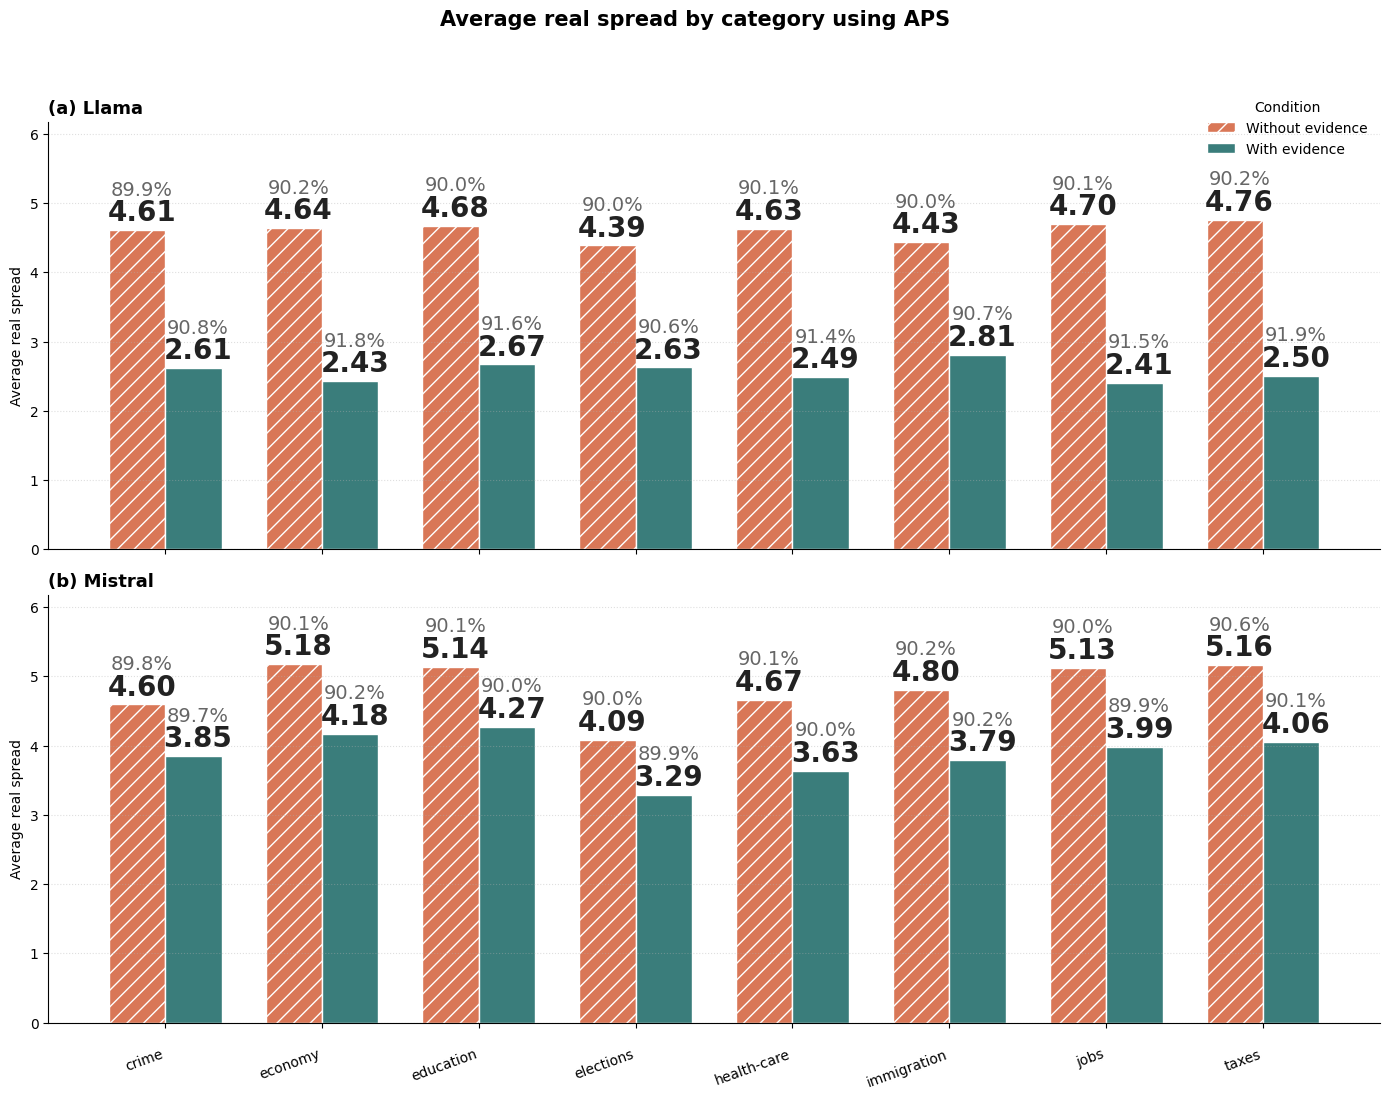

In [9]:
import ast
import pandas as pd
import numpy as np

LABEL_ORDER = ["true", "mostly-true", "half-true", "mostly-false", "false", "pants-fire"]
LABEL_TO_INDEX = {label: i for i, label in enumerate(LABEL_ORDER)}

def parse_prediction_set(value):
    if isinstance(value, str):
        return ast.literal_eval(value)
    return value

def real_spread(prediction_set):
    labels = parse_prediction_set(prediction_set)
    indices = [LABEL_TO_INDEX[l] for l in labels if l in LABEL_TO_INDEX]
    if not indices:
        return np.nan
    return (max(indices) - min(indices)) + 1  # inclusive span length

def add_spread(df):
    df = df.copy()
    df["real_spread"] = df["prediction_set"].apply(real_spread)
    return df

def summarize_spread(csv_dict, name):
    rows = []
    for cat, path in csv_dict.items():
        df = pd.read_csv(path)
        df = add_spread(df)
        rows.append({
            "category": cat,
            "mean_spread": df["real_spread"].mean(),
            "median_spread": df["real_spread"].median(),
            "pct_spread_ge_4": (df["real_spread"] >= 4).mean(),
        })
    out = pd.DataFrame(rows).sort_values("category")
    print(f"\n{name}")
    print(out.to_string(index=False, formatters={
        "mean_spread": "{:.2f}".format,
        "median_spread": "{:.1f}".format,
        "pct_spread_ge_4": "{:.1%}".format,
    }))
    return out

# Llama
summarize_spread(no_evidence_aps_llama_csv, "Llama - no evidence")
summarize_spread(with_evidence_aps_llama_csv, "Llama - with evidence")

# Mistral
summarize_spread(no_evidence_aps_mistral_csv, "Mistral - no evidence")
summarize_spread(with_evidence_aps_mistral_csv, "Mistral - with evidence")


import matplotlib.pyplot as plt


def spread_and_coverage(csv_dict):
    rows = []
    for cat, path in csv_dict.items():
        df = pd.read_csv(path)
        df = add_spread(df)
        rows.append({
            "category": cat,
            "mean_spread": df["real_spread"].mean(),
            "coverage": df["is_covered"].mean(),
        })
    out = pd.DataFrame(rows).sort_values("category")
    return out

def _plot_spread_panel(ax, categories, no_spread, with_spread, no_cov, with_cov,
                       title, show_legend, show_xticklabels):
    x = np.arange(len(categories))
    width = 0.36

    ax.bar(
        x - width / 2,
        no_spread,
        width,
        label="Without evidence",
        color="#d97757",
        edgecolor="white",
        hatch="//",
    )
    ax.bar(
        x + width / 2,
        with_spread,
        width,
        label="With evidence",
        color="#3a7d7b",
        edgecolor="white",
    )

    def annotate(xi, spread_val, cov_val):
        ax.text(
            xi + 0.03,
            spread_val + 0.05,
            f"{spread_val:.2f}",
            ha="center",
            va="bottom",
            fontsize=20,
            fontweight="bold",
            color="#222",
        )
        ax.text(
            xi + 0.03,
            spread_val + 0.45,
            f"{cov_val * 100:.1f}%",
            ha="center",
            va="bottom",
            fontsize=14,
            color="#666",
        )

    for xi, s, c in zip(x - width / 2, no_spread, no_cov):
        annotate(xi, s, c)
    for xi, s, c in zip(x + width / 2, with_spread, with_cov):
        annotate(xi, s, c)

    ax.set_xticks(x)
    if show_xticklabels:
        ax.set_xticklabels(categories, rotation=20, ha="right")
        ax.tick_params(axis="x", pad=14)
    else:
        ax.set_xticklabels([])

    ax.set_ylabel("Average real spread")
    ax.set_title(title, fontsize=13, fontweight="bold", loc="left")
    ax.grid(axis="y", linestyle=":", alpha=0.4)

    if show_legend:
        ax.legend(title="Condition", frameon=False,
                  loc="upper right", bbox_to_anchor=(1.0, 1.08))

def plot_real_spread_by_category(
    no_evidence_aps_llama_csv,
    with_evidence_aps_llama_csv,
    no_evidence_aps_mistral_csv,
    with_evidence_aps_mistral_csv,
    output_path="visualisations_APS/real_spread_by_category_APS.png",
):
    llama_no = spread_and_coverage(no_evidence_aps_llama_csv)
    llama_w  = spread_and_coverage(with_evidence_aps_llama_csv)
    mist_no  = spread_and_coverage(no_evidence_aps_mistral_csv)
    mist_w   = spread_and_coverage(with_evidence_aps_mistral_csv)

    categories = llama_no["category"].tolist()

    llama_no_s = llama_no["mean_spread"].values
    llama_w_s  = llama_w["mean_spread"].values
    mist_no_s  = mist_no["mean_spread"].values
    mist_w_s   = mist_w["mean_spread"].values

    llama_no_c = llama_no["coverage"].values
    llama_w_c  = llama_w["coverage"].values
    mist_no_c  = mist_no["coverage"].values
    mist_w_c   = mist_w["coverage"].values

    y_max = max(llama_no_s.max(), llama_w_s.max(), mist_no_s.max(), mist_w_s.max()) + 1.0

    fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(14, 11), sharex=True)

    _plot_spread_panel(
        ax_top, categories,
        llama_no_s, llama_w_s, llama_no_c, llama_w_c,
        title="(a) Llama", show_legend=True, show_xticklabels=False
    )
    _plot_spread_panel(
        ax_bot, categories,
        mist_no_s, mist_w_s, mist_no_c, mist_w_c,
        title="(b) Mistral", show_legend=False, show_xticklabels=True
    )

    ax_top.set_ylim(0, y_max)
    ax_bot.set_ylim(0, y_max)

    fig.suptitle(
        "Average real spread by category using APS",
        fontsize=15, fontweight="bold", y=0.995,
    )

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)

plot_real_spread_by_category(
    no_evidence_aps_llama_csv,
    with_evidence_aps_llama_csv,
    no_evidence_aps_mistral_csv,
    with_evidence_aps_mistral_csv,
)

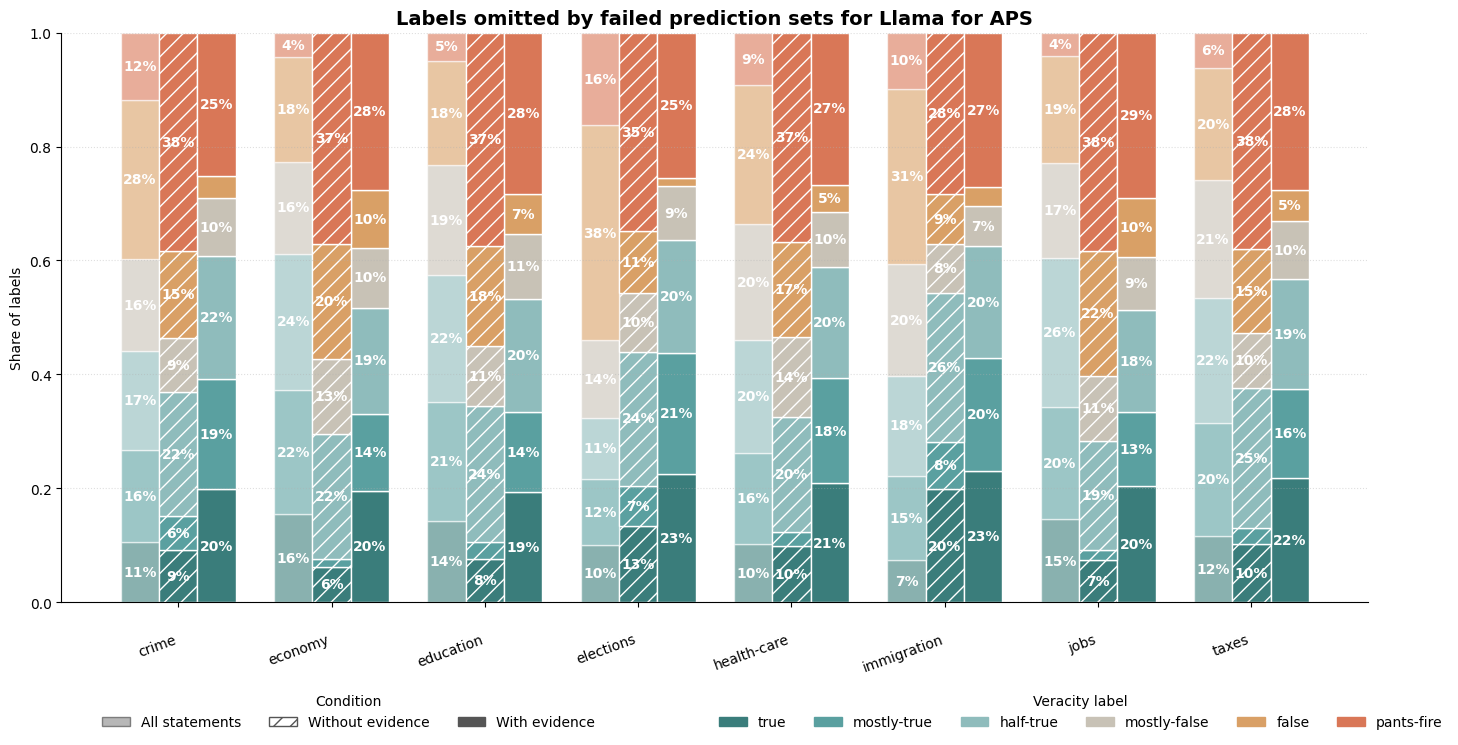

Saved: visualisations_APS/failed_set_omissions_by_category.png


In [14]:
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

LABEL_ORDER = ["true", "mostly-true", "half-true", "mostly-false", "false", "pants-fire"]

def parse_prediction_set(value):
    if isinstance(value, str):
        return ast.literal_eval(value)
    return value

def get_failed_set_label_distribution(csv_path):
    df = pd.read_csv(csv_path)

    if "is_covered" not in df.columns:
        raise ValueError(f"{csv_path} does not contain an 'is_covered' column.")

    total_prediction_sets = len(df)
    failed_df = df[df["is_covered"] == False].copy()
    failed_df["prediction_set"] = failed_df["prediction_set"].apply(parse_prediction_set)

    omitted_counts = {label: 0 for label in LABEL_ORDER}
    total_omissions = 0

    for pred_set in failed_df["prediction_set"]:
        pred_set = set(pred_set)
        omitted_labels = [label for label in LABEL_ORDER if label not in pred_set]
        for label in omitted_labels:
            omitted_counts[label] += 1
            total_omissions += 1

    if total_omissions == 0:
        proportions = pd.Series({label: 0 for label in LABEL_ORDER})
    else:
        proportions = pd.Series(
            {label: omitted_counts[label] / total_omissions for label in LABEL_ORDER}
        )

    failed_rate = len(failed_df) / total_prediction_sets if total_prediction_sets else 0
    return proportions, len(failed_df), failed_rate

def get_all_statements_label_distribution(csv_path):
    df = pd.read_csv(csv_path)

    if "true_verdict" not in df.columns:
        raise ValueError(f"{csv_path} does not contain a 'true_verdict' column.")

    counts = df["true_verdict"].value_counts().reindex(LABEL_ORDER, fill_value=0)
    proportions = counts / counts.sum() if counts.sum() else counts
    return proportions, len(df)

def plot_failed_set_omissions(no_evidence_aps_llama_csv, with_evidence_aps_llama_csv, output_path="visualisations_APS/failed_set_omissions_by_category_aps.png"):
    categories = list(no_evidence_aps_llama_csv.keys())

    label_colors = {
        "true": "#3a7d7b",
        "mostly-true": "#5aa0a0",
        "half-true": "#8fbcbc",
        "mostly-false": "#c8c2b6",
        "false": "#d9a066",
        "pants-fire": "#d97757",
    }

    no_data = {}
    with_data = {}
    all_data = {}
    no_failed_rates = {}
    with_failed_rates = {}

    for category in categories:
        no_props, no_failed, no_failed_rate = get_failed_set_label_distribution(no_evidence_aps_llama_csv[category])
        with_props, with_failed, with_failed_rate = get_failed_set_label_distribution(with_evidence_aps_llama_csv[category])
        all_props, total_count = get_all_statements_label_distribution(no_evidence_aps_llama_csv[category])

        no_data[category] = no_props
        with_data[category] = with_props
        all_data[category] = all_props
        no_failed_rates[category] = no_failed_rate
        with_failed_rates[category] = with_failed_rate

    x = np.arange(len(categories))
    width = 0.25

    fig, ax = plt.subplots(figsize=(15, 8))

    no_bottom = np.zeros(len(categories))
    with_bottom = np.zeros(len(categories))
    all_bottom = np.zeros(len(categories))

    for label in LABEL_ORDER:
        no_vals = np.array([no_data[cat][label] for cat in categories])
        with_vals = np.array([with_data[cat][label] for cat in categories])
        all_vals = np.array([all_data[cat][label] for cat in categories])

        ax.bar(
            x - width,
            all_vals,
            width,
            bottom=all_bottom,
            color=label_colors[label],
            edgecolor="white",
            alpha=0.6,
        )
        ax.bar(
            x,
            no_vals,
            width,
            bottom=no_bottom,
            color=label_colors[label],
            edgecolor="white",
            hatch="//",
        )
        ax.bar(
            x + width,
            with_vals,
            width,
            bottom=with_bottom,
            color=label_colors[label],
            edgecolor="white",
        )

        for xi, bottom, val in zip(x - width, all_bottom, all_vals):
            if val >= 0.04:
                ax.text(
                    xi,
                    bottom + val / 2,
                    f"{val:.0%}",
                    ha="center",
                    va="center",
                    fontsize=10,
                    color="white",
                    fontweight="bold",
                )

        for xi, bottom, val in zip(x, no_bottom, no_vals):
            if val >= 0.04:
                ax.text(
                    xi,
                    bottom + val / 2,
                    f"{val:.0%}",
                    ha="center",
                    va="center",
                    fontsize=10,
                    color="white",
                    fontweight="bold",
                )

        for xi, bottom, val in zip(x + width, with_bottom, with_vals):
            if val >= 0.04:
                ax.text(
                    xi,
                    bottom + val / 2,
                    f"{val:.0%}",
                    ha="center",
                    va="center",
                    fontsize=10,
                    color="white",
                    fontweight="bold",
                )

        all_bottom += all_vals
        no_bottom += no_vals
        with_bottom += with_vals

    ax.set_ylim(0, 1)
    ax.set_xticks(x)
    ax.set_xticklabels(categories, rotation=20, ha="right")
    ax.tick_params(axis="x", pad=18)
    ax.set_ylabel("Share of labels")
    ax.set_title("Labels omitted by failed prediction sets for Llama for APS", fontsize=14, fontweight="bold")
    ax.grid(axis="y", linestyle=":", alpha=0.4)

    condition_handles = [
        plt.Rectangle((0, 0), 1, 1, facecolor="#999", edgecolor="#555", alpha=0.7, label="All statements"),
        plt.Rectangle((0, 0), 1, 1, facecolor="white", edgecolor="#555", hatch="//", label="Without evidence"),
        plt.Rectangle((0, 0), 1, 1, facecolor="#555", edgecolor="#555", label="With evidence"),
    ]
    label_handles = [
        plt.Rectangle((0, 0), 1, 1, color=label_colors[label], label=label)
        for label in LABEL_ORDER
    ]

    leg1 = ax.legend(
        handles=condition_handles,
        title="Condition",
        bbox_to_anchor=(0.22, -0.14),
        loc="upper center",
        ncol=3,
        frameon=False,
    )
    ax.add_artist(leg1)

    ax.legend(
        handles=label_handles,
        title="Veracity label",
        bbox_to_anchor=(0.78, -0.14),
        loc="upper center",
        ncol=6,
        frameon=False,
    )

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.24)
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)

plot_failed_set_omissions(no_evidence_aps_llama_csv, with_evidence_aps_llama_csv)
print("Saved: visualisations_APS/failed_set_omissions_by_category.png")

In [ ]:
# Give me the set of statements where the Llama model with evidence gave a prediction set of size 5 for the crime category. Also look at the crime dataset found here: datasets\politifact-crime.json and give me the year and author for each of those statements.

import json
import re
import unicodedata
import pandas as pd

csv_path = r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/results/llama/zero-shot-aps/crime/conformal_results_aps_all_trials_100trials_20260501_010529.csv"
json_path = r"C:/Sebi/Master/code/Simple-Test-LLMs-Politifact/datasets/politifact-crime.json"

def normalize_statement(s):
    s = str(s).strip()
    s = unicodedata.normalize("NFKD", s)
    s = s.translate({
        ord("“"): '"', ord("”"): '"',
        ord("‘"): "'", ord("’"): "'",
    })
    s = re.sub(r"\s+", " ", s)
    return s.casefold()

# Results CSV (with evidence)
df = pd.read_csv(csv_path)
df5 = df[df["set_size"] == 5].copy()
df5["statement_norm"] = df5["statement"].map(normalize_statement)

# Crime dataset
with open(json_path, "r", encoding="utf-8") as f:
    crime_data = json.load(f)

crime_df = pd.DataFrame(crime_data)
crime_df["statement_norm"] = crime_df["statement"].map(normalize_statement)

# Join and extract year + author
merged = df5.merge(crime_df, on="statement_norm", how="left", suffixes=("_pred", "_crime"))
merged["year"] = merged["statement_date"].str.extract(r"(\d{4})")
merged["author"] = merged["statement_originator"]

result = merged[["statement_pred", "year", "author"]].rename(
    columns={"statement_pred": "statement"}
)

result = result.drop_duplicates(subset=["statement"], keep="first")

result = result.sort_values(
    by=["year", "statement"],
    key=lambda s: pd.to_numeric(s, errors="coerce"),
    ascending=False
).reset_index(drop=True)
# print(result.to_string(index=False))

# Optional: see statements that failed to match the dataset
missing = merged[merged["author"].isna()][["statement_pred"]]
if not missing.empty:
    print("\nUnmatched statements:")
    print(missing.to_string(index=False))


# Now for each year print the number of statements with size 5 prediction sets

size5_counts = result.groupby("year").size().reset_index(name="size_5_count")
print(size5_counts.to_string(index=False))




year  size_5_count
2007            11
2008             4
2009             6
2010            63
2011            47
2012            47
2013            67
2014            82
2015            51
2016            86
2017            86
2018            66
2019            45
2020            55
2021            35
2022            45
2023            20
2024            20
2025             6
2026             1
